# 第42篇｜回归模型评估：R² / MSE / 残差分析

> 这是「数据分析从入门到精通」系列的第 42 篇。模型建出来了，好不好用怎么判断？这篇来聊回归模型评估——R²、MSE、RMSE 各自代表什么，残差图怎么看，让你建完模型有底气说"这个模型靠谱"。

---

嗨，我是小荷～

建完模型，怎么判断它好不好？不能只看 R²——R² 高不代表模型真的可用，残差分析才是关键。

今天系统讲三类评估手段：**评估指标（R²/MSE/MAE）、残差分析、预测误差可视化**。

---

## 一、常用评估指标

分类模型好不好，看这几个指标：


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error,
                              mean_absolute_error, mean_absolute_percentage_error)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
n = 300

X_data = np.random.uniform(10, 100, (n, 3))
y_data = 50 + 2.5*X_data[:,0] - 1.2*X_data[:,1] + 0.8*X_data[:,2] + np.random.normal(0, 20, n)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("回归模型评估指标")
print("="*45)
print(f"R²     = {r2:.4f}   （越接近1越好，解释了{r2*100:.1f}%的方差）")
print(f"MSE    = {mse:.2f}  （均方误差，对大误差敏感）")
print(f"RMSE   = {rmse:.2f}  （与y同量纲，平均误差约±{rmse:.1f}）")
print(f"MAE    = {mae:.2f}  （平均绝对误差，更鲁棒）")
print(f"MAPE   = {mape:.1f}%  （平均绝对百分比误差）")


回归模型评估指标
R²     = 0.9363   （越接近1越好，解释了93.6%的方差）
MSE    = 447.57  （均方误差，对大误差敏感）
RMSE   = 21.16  （与y同量纲，平均误差约±21.2）
MAE    = 17.13  （平均绝对误差，更鲁棒）
MAPE   = 30.5%  （平均绝对百分比误差）


| 指标 | 含义 | 优点 | 缺点 |
|------|------|------|------|
| R² | 解释方差比例 | 直观，0~1 | 变量越多 R² 越高（虚高） |
| Adjusted R² | 调整自由度 | 可比较不同变量数的模型 | — |
| MSE | 均方误差 | 对大误差敏感（惩罚异常） | 不直观（量纲是 y² ） |
| RMSE | 均方根误差 | 与 y 同量纲，直观 | 对异常值敏感 |
| MAE | 平均绝对误差 | 对异常值更鲁棒 | 不可微（梯度下降不常用） |
| MAPE | 百分比误差 | 跨量纲对比 | y 接近 0 时不稳定 |

---

## 二、残差分析：4 张诊断图

残差图是诊断模型是否合适的核心工具：


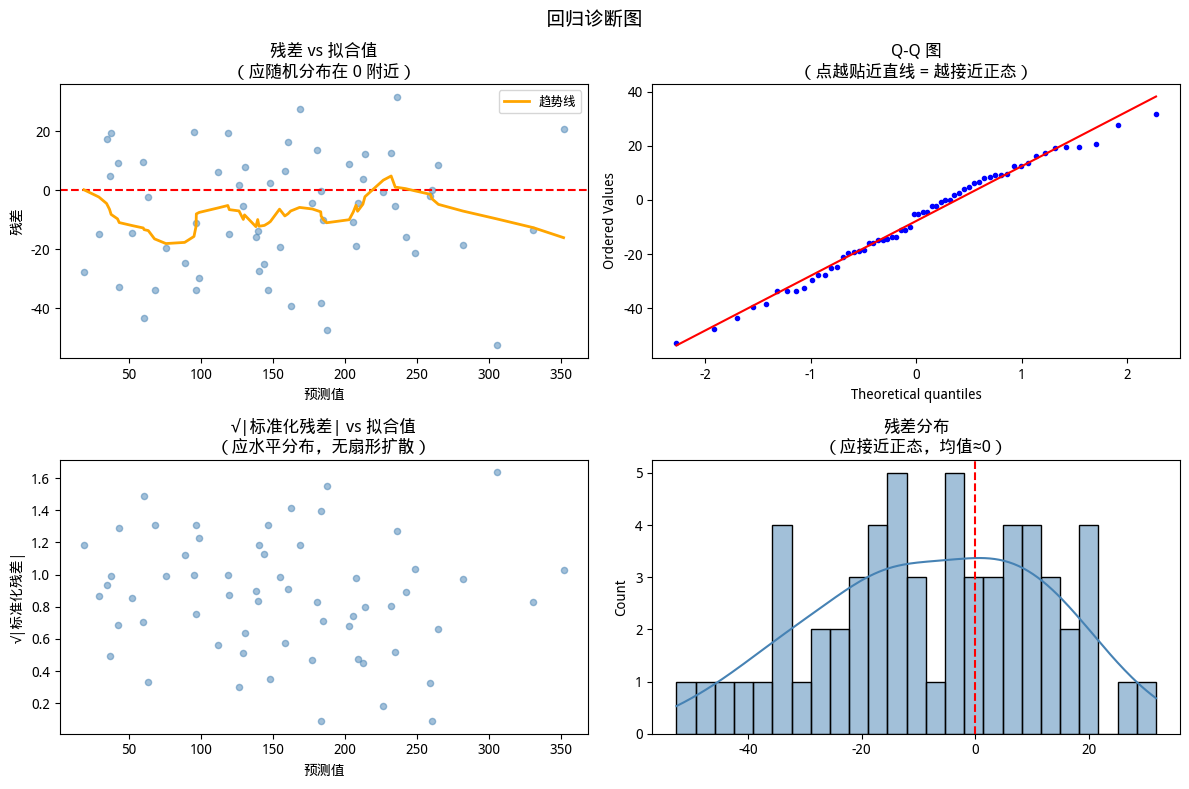

In [2]:
residuals = y_test - y_pred
y_pred_sorted_idx = np.argsort(y_pred)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ── 图1：残差 vs 拟合值 ──
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, color='steelblue', s=20)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('残差 vs 拟合值\n（应随机分布在 0 附近）', fontweight='bold')
axes[0, 0].set_xlabel('预测值')
axes[0, 0].set_ylabel('残差')

# 加 LOWESS 平滑线
from scipy.signal import savgol_filter
x_sort = y_pred[y_pred_sorted_idx]
r_sort = residuals[y_pred_sorted_idx]
if len(x_sort) > 10:
    r_smooth = savgol_filter(r_sort, window_length=min(21, len(r_sort)//3*2+1), polyorder=2)
    axes[0, 0].plot(x_sort, r_smooth, 'orange', linewidth=2, label='趋势线')
    axes[0, 0].legend(fontsize=9)

# ── 图2：Q-Q 图（检验残差正态性）──
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q 图\n（点越贴近直线 = 越接近正态）', fontweight='bold')
axes[0, 1].get_lines()[0].set_markersize(3)

# ── 图3：标准化残差的绝对值（检验方差齐性）──
std_resid = residuals / residuals.std()
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(std_resid)), alpha=0.5, color='steelblue', s=20)
axes[1, 0].set_title('√|标准化残差| vs 拟合值\n（应水平分布，无扇形扩散）', fontweight='bold')
axes[1, 0].set_xlabel('预测值')
axes[1, 0].set_ylabel('√|标准化残差|')

# ── 图4：残差分布直方图 ──
sns.histplot(residuals, bins=25, kde=True, color='steelblue', ax=axes[1, 1])
axes[1, 1].set_title('残差分布\n（应接近正态，均值≈0）', fontweight='bold')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)

plt.suptitle('回归诊断图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 如何读懂残差图？

| 图表 | 理想状态 | 问题信号 |
|------|---------|---------|
| 残差 vs 拟合值 | 随机散布在 0 周围 | 有规律的曲线 → 线性假设不成立 |
| Q-Q 图 | 点在对角线上 | 偏离 → 残差非正态 |
| √|残差| vs 拟合值 | 水平带状分布 | 扇形扩散 → 异方差 |
| 残差直方图 | 钟形，中心在 0 | 偏斜 → 系统偏差 |

---

## 三、真实值 vs 预测值

来对比一下两者的差异：


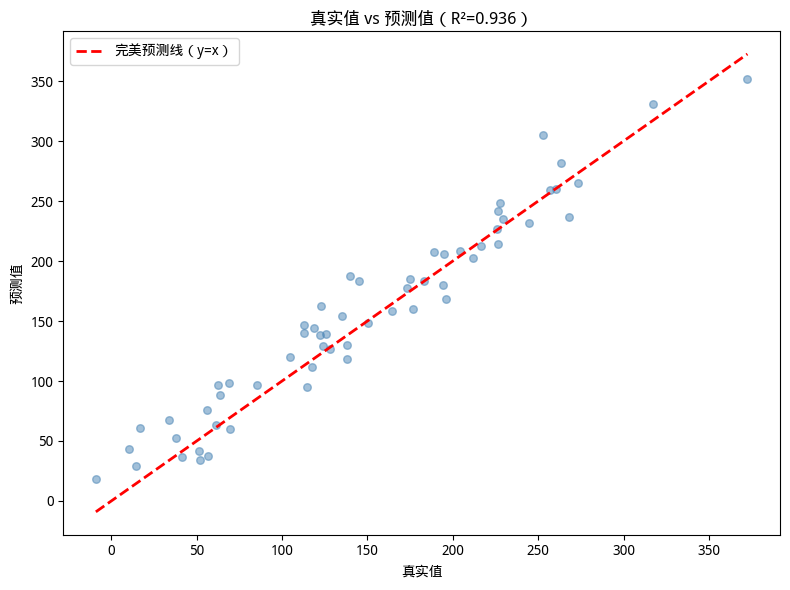

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='完美预测线（y=x）')

ax.set_title(f'真实值 vs 预测值（R²={r2:.3f}）', fontweight='bold')
ax.set_xlabel('真实值')
ax.set_ylabel('预测值')
ax.legend()
plt.tight_layout()
plt.show()


理想情况下，所有点应该在对角线上。偏离越多，模型越不准。

---

## 四、交叉验证：更可靠的评估

单次训练/测试集划分结果有随机性，用 K 折交叉验证更稳定：


In [4]:
from sklearn.model_selection import cross_val_score

cv_r2   = cross_val_score(LinearRegression(), X_data, y_data, cv=5, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(LinearRegression(), X_data, y_data, cv=5, scoring='neg_mean_squared_error'))

print("\n5 折交叉验证结果：")
print(f"R²   均值 = {cv_r2.mean():.4f}，标准差 = {cv_r2.std():.4f}")
print(f"RMSE 均值 = {cv_rmse.mean():.2f}，标准差 = {cv_rmse.std():.2f}")



5 折交叉验证结果：
R²   均值 = 0.9328，标准差 = 0.0207
RMSE 均值 = 19.39，标准差 = 1.25


---

## 五、📝 小结

评估回归模型的完整流程：
1. **看 R²**：模型解释力是否足够
2. **看 RMSE/MAE**：预测误差是否可接受（结合业务判断）
3. **画残差图**：诊断线性/正态/方差齐性假设
4. **交叉验证**：评估结果是否稳定可靠

---

## 六、🏋️ 课后练习

1. 对下面的房价模型，画 4 张诊断图，判断模型假设是否成立。
2. 用 5 折交叉验证计算 RMSE，与单次测试集的 RMSE 对比，看结果是否稳定。
3. 如果残差 vs 拟合值图呈现 U 形曲线，意味着什么？应该怎么处理？

In [5]:
# 构造房价模拟数据
np.random.seed(42)
n = 200

# 生成特征
area = np.random.uniform(50, 200, n)
distance_subway = np.random.uniform(0.1, 5, n)
year_built = np.random.randint(2000, 2025, n)
floor = np.random.randint(1, 33, n)
school_district = np.random.randint(0, 2, n)

# 生成房价
price = (0.5 * area - 5 * distance_subway + 0.3 * (year_built - 2000)
         + 2 * floor + 10 * school_district + np.random.normal(0, 10, n)) * 10000

# 创建DataFrame
df = pd.DataFrame({
    '面积(㎡)': area,
    '距地铁(km)': distance_subway,
    '建造年份': year_built,
    '楼层': floor,
    '是否学区': school_district,
    '房价(万元)': price / 10000
})

# 准备数据
features = ['面积(㎡)', '距地铁(km)', '建造年份', '楼层', '是否学区']
X = df[features]
y = df['房价(万元)']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练模型
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred


残差均值: 4.0066
残差均值偏离0，可能存在偏差
Q-Q图R²: 0.9914
残差近似正态分布 ✓

发现 1 个高杠杆点
  样本29: 杠杆值=0.304, 标准化残差=1.52


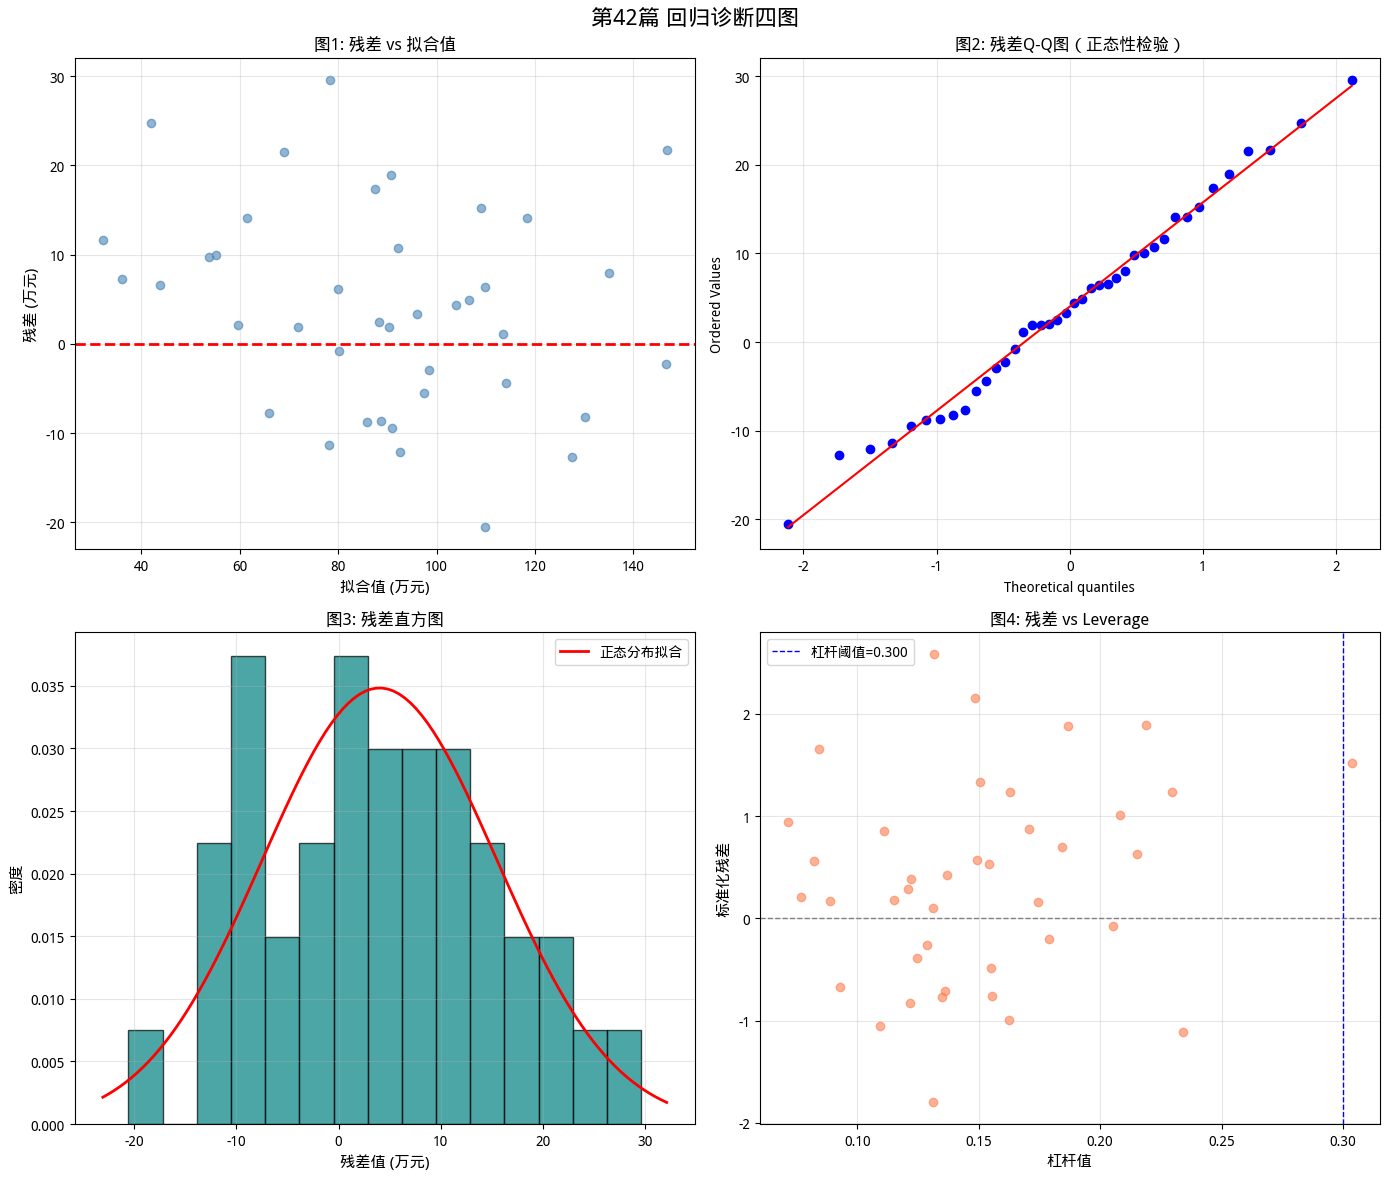


模型假设检验总结：
----------------------------------------
1. 线性假设: 残差vs拟合值应无明显模式
2. 正态假设: Q-Q图点应接近对角线
3. 同方差假设: 残差应等宽分布
4. 独立同分布: 杠杆图检查异常点


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('第42篇 回归诊断四图', fontsize=16, fontweight='bold')

# 图1：残差 vs 拟合值
ax1 = axes[0, 0]
ax1.scatter(y_pred, residuals, alpha=0.6, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('拟合值 (万元)', fontsize=11)
ax1.set_ylabel('残差 (万元)', fontsize=11)
ax1.set_title('图1: 残差 vs 拟合值', fontsize=12)
ax1.grid(True, alpha=0.3)

# 检查是否有模式
residual_mean = residuals.mean()
print(f"\n残差均值: {residual_mean:.4f}")
if abs(residual_mean) < 1:
    print("残差均值接近0，随机分布 ✓")
else:
    print("残差均值偏离0，可能存在偏差")

# 图2：Q-Q图
ax2 = axes[0, 1]
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('图2: 残差Q-Q图（正态性检验）', fontsize=12)
ax2.grid(True, alpha=0.3)

# 计算相关系数判断正态性
osm, osr = stats.probplot(residuals, dist="norm", fit=False)
r_squared = np.corrcoef(osm, osr)[0, 1]**2
print(f"Q-Q图R²: {r_squared:.4f}")
if r_squared > 0.95:
    print("残差近似正态分布 ✓")
else:
    print("残差可能偏离正态分布")

# 图3：残差直方图
ax3 = axes[1, 0]
ax3.hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='teal', density=True)
# 叠加正态分布曲线
xmin, xmax = ax3.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, residuals.mean(), residuals.std())
ax3.plot(x, p, 'r-', linewidth=2, label='正态分布拟合')
ax3.set_xlabel('残差值 (万元)', fontsize=11)
ax3.set_ylabel('密度', fontsize=11)
ax3.set_title('图3: 残差直方图', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 图4：残差 vs Leverage（杠杆值）
ax4 = axes[1, 1]
# 计算杠杆值
X_test_array = X_test.values
X_test_with_intercept = np.c_[np.ones(len(X_test_array)), X_test_array]
H = X_test_with_intercept @ np.linalg.inv(X_test_with_intercept.T @ X_test_with_intercept) @ X_test_with_intercept.T
leverage = np.diag(H)

# 标准化残差
standardized_residuals = residuals / residuals.std()

# 高杠杆值阈值（2*(k+1)/n）
threshold = 2 * (X_test.shape[1] + 1) / len(X_test)
ax4.scatter(leverage, standardized_residuals, alpha=0.6, color='coral')
ax4.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax4.axvline(x=threshold, color='blue', linestyle='--', linewidth=1, label=f'杠杆阈值={threshold:.3f}')
ax4.set_xlabel('杠杆值', fontsize=11)
ax4.set_ylabel('标准化残差', fontsize=11)
ax4.set_title('图4: 残差 vs Leverage', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 标注高杠杆点
high_leverage = leverage > threshold
if high_leverage.any():
    print(f"\n发现 {high_leverage.sum()} 个高杠杆点")
    for i in np.where(high_leverage)[0]:
        print(f"  样本{i}: 杠杆值={leverage[i]:.3f}, 标准化残差={float(standardized_residuals.iloc[i]):.2f}")

plt.tight_layout()
plt.show()

print("\n模型假设检验总结：")
print("-" * 40)
print("1. 线性假设: 残差vs拟合值应无明显模式")
print("2. 正态假设: Q-Q图点应接近对角线")
print("3. 同方差假设: 残差应等宽分布")
print("4. 独立同分布: 杠杆图检查异常点")

In [8]:
from sklearn.model_selection import  KFold

print("练习2：5折交叉验证 RMSE vs 单次测试集 RMSE")

# 单次测试集RMSE
single_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
single_r2 = r2_score(y_test, y_pred)

print(f"\n单次测试集评估：")
print(f"  RMSE: {single_rmse:.4f}")
print(f"  R²: {single_r2:.4f}")

# 5折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print(f"\n5折交叉验证结果：")
print(f"  各折RMSE: {cv_rmse.round(4)}")
print(f"  平均RMSE: {cv_rmse.mean():.4f}")
print(f"  RMSE标准差: {cv_rmse.std():.4f}")

print(f"\n对比分析：")
print(f"  单次测试RMSE: {single_rmse:.4f}")
print(f"  交叉验证平均RMSE: {cv_rmse.mean():.4f}")
print(f"  差异: {abs(single_rmse - cv_rmse.mean()):.4f}")

if abs(single_rmse - cv_rmse.mean()) < 5:
    print("单次测试与交叉验证结果接近，模型稳定性良好 ✓")
else:
    print("两者差异较大，可能存在过拟合或数据分布不均")

练习2：5折交叉验证 RMSE vs 单次测试集 RMSE

单次测试集评估：
  RMSE: 11.9984
  R²: 0.8134

5折交叉验证结果：
  各折RMSE: [11.9984 10.7121 10.6332 10.7091  9.8035]
  平均RMSE: 10.7713
  RMSE标准差: 0.7027

对比分析：
  单次测试RMSE: 11.9984
  交叉验证平均RMSE: 10.7713
  差异: 1.2271
单次测试与交叉验证结果接近，模型稳定性良好 ✓


练习3：U形残差的识别与处理

线性回归拟合二次数据：
  线性模型 R²: 0.9239


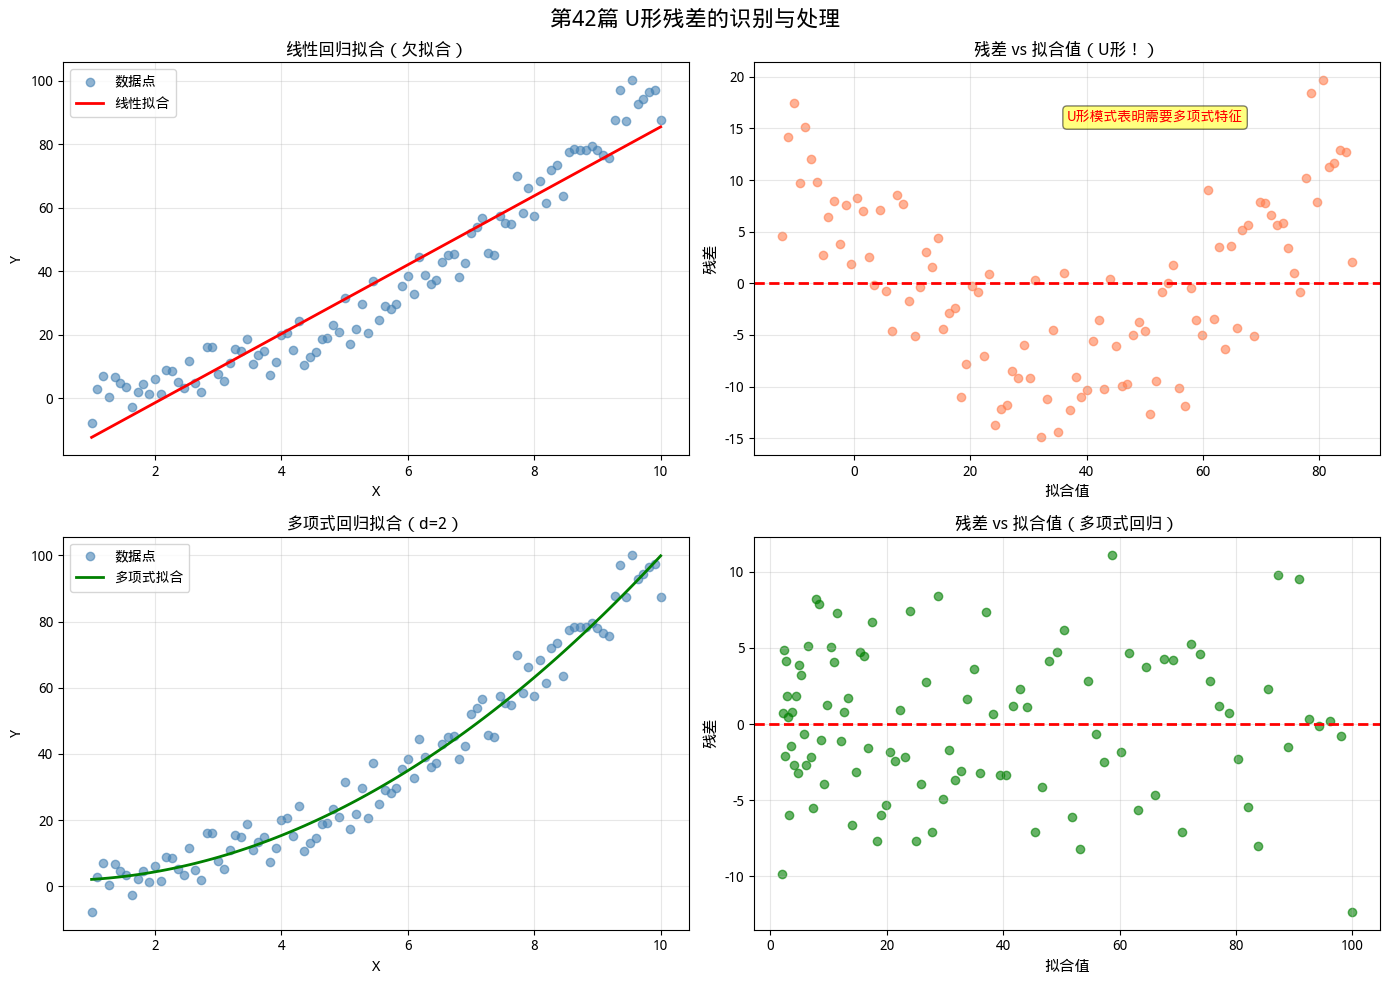


处理前后对比：
----------------------------------------
线性回归 R²: 0.9239
多项式回归 R²: 0.9737

U形残差的含义：
如果残差 vs 拟合值图呈现U形曲线，意味着：
1. 数据存在非线性关系，线性模型无法捕捉
2. 残差不是随机分布的，存在系统性模式
3. 模型假设不成立，需要改进模型

处理方法：
1. 添加多项式特征（x², x³等）
2. 对特征进行对数/指数变换
3. 使用非线性模型（决策树、SVM等）
4. 考虑分箱或分段线性回归

总结
1. 诊断图可检验模型假设是否成立
2. 交叉验证比单次测试更可靠
3. U形残差表明需要非线性建模


In [11]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
print("练习3：U形残差的识别与处理")

# 构造U形数据
np.random.seed(100)
n_u = 100
X_u = np.linspace(1, 10, n_u)
y_u = X_u**2 + np.random.normal(0, 5, n_u)  # 真实的二次关系

# 使用线性回归拟合（会产生U形残差）
X_u_reshape = X_u.reshape(-1, 1)
model_linear = LinearRegression()
model_linear.fit(X_u_reshape, y_u)
y_u_pred_linear = model_linear.predict(X_u_reshape)
residuals_u = y_u - y_u_pred_linear

print("\n线性回归拟合二次数据：")
print(f"  线性模型 R²: {r2_score(y_u, y_u_pred_linear):.4f}")

# 图：展示U形残差
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('第42篇 U形残差的识别与处理', fontsize=16, fontweight='bold')

# 图1：线性拟合结果
ax1 = axes[0, 0]
ax1.scatter(X_u, y_u, alpha=0.6, label='数据点', color='steelblue')
ax1.plot(X_u, y_u_pred_linear, color='red', linewidth=2, label='线性拟合')
ax1.set_xlabel('X', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.set_title('线性回归拟合（欠拟合）', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2：U形残差
ax2 = axes[0, 1]
ax2.scatter(y_u_pred_linear, residuals_u, alpha=0.6, color='coral')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('拟合值', fontsize=11)
ax2.set_ylabel('残差', fontsize=11)
ax2.set_title('残差 vs 拟合值（U形！）', fontsize=12)
ax2.grid(True, alpha=0.3)

# 添加U形拟合线
u_x = np.linspace(y_u_pred_linear.min(), y_u_pred_linear.max(), 50)
ax2.text(0.5, 0.85, 'U形模式表明需要多项式特征',
         transform=ax2.transAxes, fontsize=10, color='red',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# 使用多项式回归处理
poly = PolynomialFeatures(degree=2)
X_u_poly = poly.fit_transform(X_u.reshape(-1, 1))
model_poly = LinearRegression()
model_poly.fit(X_u_poly, y_u)
y_u_pred_poly = model_poly.predict(X_u_poly)
residuals_u_poly = y_u - y_u_pred_poly

# 图3：多项式拟合结果
ax3 = axes[1, 0]
ax3.scatter(X_u, y_u, alpha=0.6, label='数据点', color='steelblue')
X_u_sorted_idx = np.argsort(X_u)
ax3.plot(X_u[X_u_sorted_idx], y_u_pred_poly[X_u_sorted_idx], color='green', linewidth=2, label='多项式拟合')
ax3.set_xlabel('X', fontsize=11)
ax3.set_ylabel('Y', fontsize=11)
ax3.set_title('多项式回归拟合（d=2）', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 图4：多项式回归的残差
ax4 = axes[1, 1]
ax4.scatter(y_u_pred_poly, residuals_u_poly, alpha=0.6, color='green')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('拟合值', fontsize=11)
ax4.set_ylabel('残差', fontsize=11)
ax4.set_title('残差 vs 拟合值（多项式回归）', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n处理前后对比：")
print("-" * 40)
print(f"线性回归 R²: {r2_score(y_u, y_u_pred_linear):.4f}")
print(f"多项式回归 R²: {r2_score(y_u, y_u_pred_poly):.4f}")

print("\nU形残差的含义：")
print("如果残差 vs 拟合值图呈现U形曲线，意味着：")
print("1. 数据存在非线性关系，线性模型无法捕捉")
print("2. 残差不是随机分布的，存在系统性模式")
print("3. 模型假设不成立，需要改进模型")

print("\n处理方法：")
print("1. 添加多项式特征（x², x³等）")
print("2. 对特征进行对数/指数变换")
print("3. 使用非线性模型（决策树、SVM等）")
print("4. 考虑分箱或分段线性回归")

print("\n" + "=" * 60)
print("总结")
print("=" * 60)
print("1. 诊断图可检验模型假设是否成立")
print("2. 交叉验证比单次测试更可靠")
print("3. U形残差表明需要非线性建模")

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 43 篇：回归诊断 — 多重共线性 / 异方差 / 自相关**
>
> 下篇学回归诊断——找出让模型变差的「元凶」，多重共线性、异方差、自相关问题一个一个解决。

---

*跟着小荷，数据分析路上不迷路～*